# Análisis del Titanic — Gráficas para la presentación.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = sns.load_dataset('titanic')

# Limpieza básica
df = df.drop(columns=['deck', 'parch'])
df['age'] = df.groupby(['sex', 'pclass'])['age'].transform(
    lambda x: x.fillna(x.mean())
)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Variable grupo
df['grupo'] = np.where(df['age'] < 16, 'Niño/a',
              np.where(df['sex'] == 'male', 'Hombre', 'Mujer'))

COLORES = {'yes': '#185FA5', 'no': '#B0AEA7'}
print('Dataset listo:', df.shape)

Dataset listo: (891, 14)


## Slide 1 — Tasa de mortalidad global.

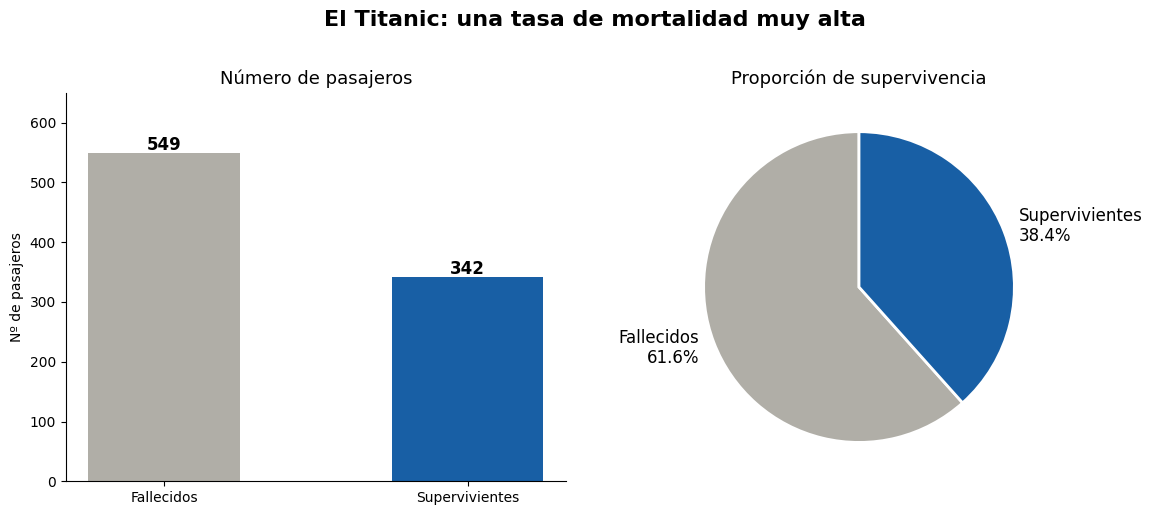

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('El Titanic: una tasa de mortalidad muy alta', fontsize=16, fontweight='bold', y=1.02)

# Absolutos
counts = df['alive'].value_counts()
colores = [COLORES['no'], COLORES['yes']]
axes[0].bar(['Fallecidos', 'Supervivientes'], [counts['no'], counts['yes']], color=colores, width=0.5)
axes[0].set_title('Número de pasajeros', fontsize=13)
axes[0].set_ylabel('Nº de pasajeros')
for i, v in enumerate([counts['no'], counts['yes']]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, 650)
axes[0].spines[['top', 'right']].set_visible(False)

# Relativos — pie
pct_no = counts['no'] / len(df) * 100
pct_yes = counts['yes'] / len(df) * 100
axes[1].pie(
    [pct_no, pct_yes],
    labels=[f'Fallecidos\n{pct_no:.1f}%', f'Supervivientes\n{pct_yes:.1f}%'],
    colors=colores, startangle=90,
    textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de supervivencia', fontsize=13)

plt.tight_layout()
plt.show()

## Slide 2 — Mujeres y niños primero.

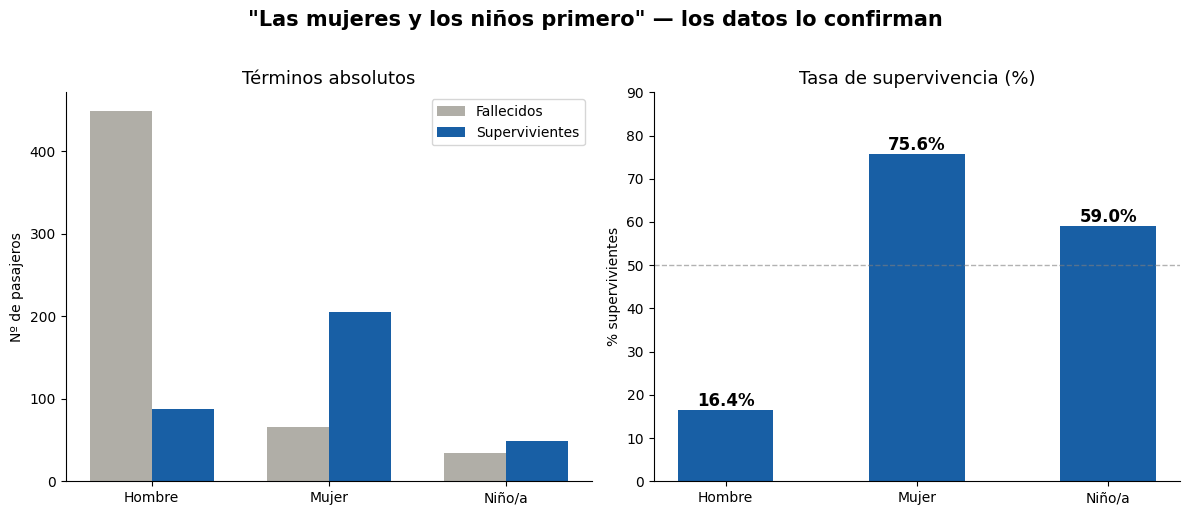

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('"Las mujeres y los niños primero" — los datos lo confirman', fontsize=15, fontweight='bold', y=1.02)

orden = ['Hombre', 'Mujer', 'Niño/a']

# Absolutos
abs_grupo = df.groupby(['grupo', 'alive']).size().unstack(fill_value=0)
abs_grupo = abs_grupo.loc[orden]
x = np.arange(len(orden))
width = 0.35
axes[0].bar(x - width/2, abs_grupo['no'], width, label='Fallecidos', color=COLORES['no'])
axes[0].bar(x + width/2, abs_grupo['yes'], width, label='Supervivientes', color=COLORES['yes'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(orden)
axes[0].set_title('Términos absolutos', fontsize=13)
axes[0].set_ylabel('Nº de pasajeros')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Relativos
rel_grupo = abs_grupo.div(abs_grupo.sum(axis=1), axis=0) * 100
axes[1].bar(orden, rel_grupo['yes'], color=COLORES['yes'], width=0.5)
for i, v in enumerate(rel_grupo['yes']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title('Tasa de supervivencia (%)', fontsize=13)
axes[1].set_ylabel('% supervivientes')
axes[1].set_ylim(0, 90)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Slide 3 — Influencia de la clase.

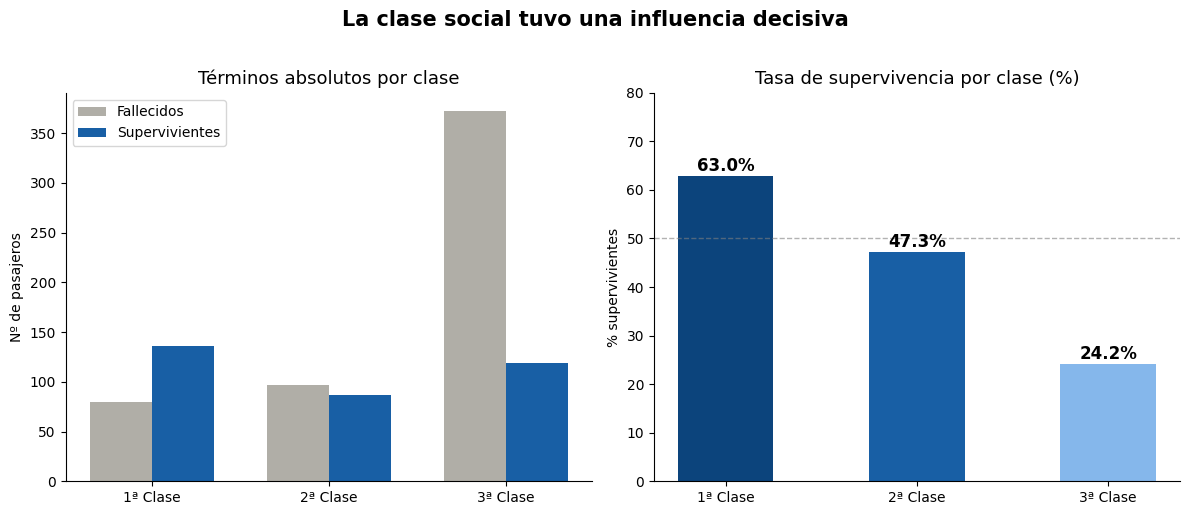

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('La clase social tuvo una influencia decisiva', fontsize=15, fontweight='bold', y=1.02)

abs_clase = df.groupby(['pclass', 'alive']).size().unstack(fill_value=0)
rel_clase = abs_clase.div(abs_clase.sum(axis=1), axis=0) * 100

# Absolutos
x = np.arange(3)
axes[0].bar(x - width/2, abs_clase['no'], width, label='Fallecidos', color=COLORES['no'])
axes[0].bar(x + width/2, abs_clase['yes'], width, label='Supervivientes', color=COLORES['yes'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'])
axes[0].set_title('Términos absolutos por clase', fontsize=13)
axes[0].set_ylabel('Nº de pasajeros')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Relativos
axes[1].bar(['1ª Clase', '2ª Clase', '3ª Clase'], rel_clase['yes'],
            color=['#0C447C', '#185FA5', '#85B7EB'], width=0.5)
for i, v in enumerate(rel_clase['yes']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title('Tasa de supervivencia por clase (%)', fontsize=13)
axes[1].set_ylabel('% supervivientes')
axes[1].set_ylim(0, 80)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Slide 4 — Clase × Género/Niños.

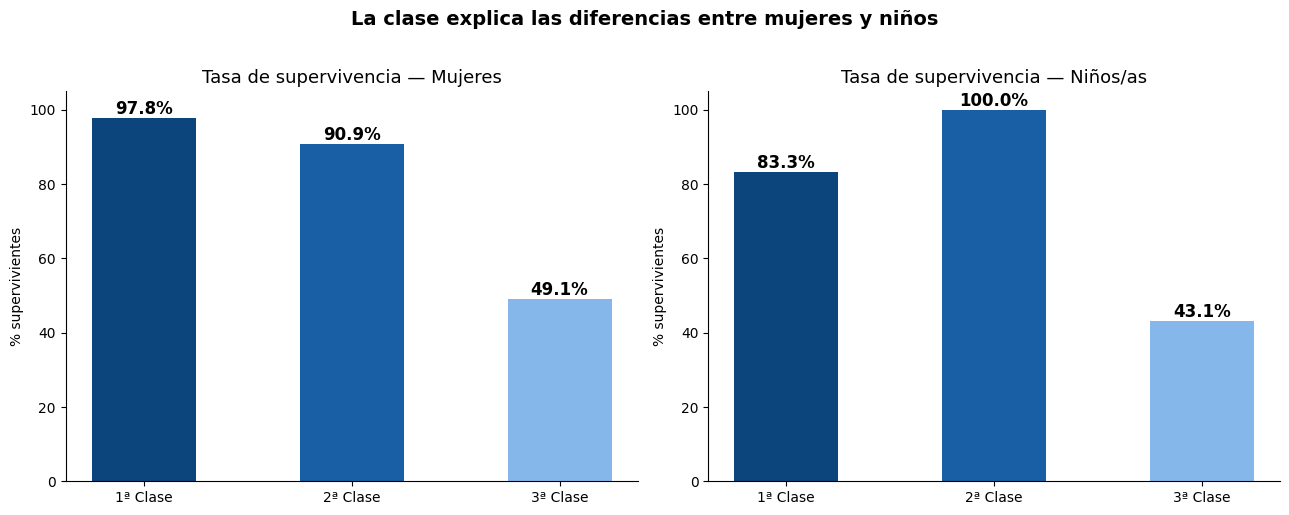

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('La clase explica las diferencias entre mujeres y niños', fontsize=14, fontweight='bold', y=1.02)

# Mujeres por clase
mujeres = df[df['grupo'] == 'Mujer']
rel_muj = mujeres.groupby(['pclass', 'alive']).size().unstack(fill_value=0)
rel_muj = rel_muj.div(rel_muj.sum(axis=1), axis=0) * 100

axes[0].bar(['1ª Clase', '2ª Clase', '3ª Clase'], rel_muj['yes'],
            color=['#0C447C', '#185FA5', '#85B7EB'], width=0.5)
for i, v in enumerate(rel_muj['yes']):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Tasa de supervivencia — Mujeres', fontsize=13)
axes[0].set_ylabel('% supervivientes')
axes[0].set_ylim(0, 105)
axes[0].spines[['top', 'right']].set_visible(False)

# Niños por clase
ninos = df[df['grupo'] == 'Niño/a']
rel_nin = ninos.groupby(['pclass', 'alive']).size().unstack(fill_value=0)
rel_nin = rel_nin.div(rel_nin.sum(axis=1), axis=0) * 100

axes[1].bar(['1ª Clase', '2ª Clase', '3ª Clase'], rel_nin['yes'],
            color=['#0C447C', '#185FA5', '#85B7EB'], width=0.5)
for i, v in enumerate(rel_nin['yes']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Tasa de supervivencia — Niños/as', fontsize=13)
axes[1].set_ylabel('% supervivientes')
axes[1].set_ylim(0, 105)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Slide 5 — Puerto de embarque.

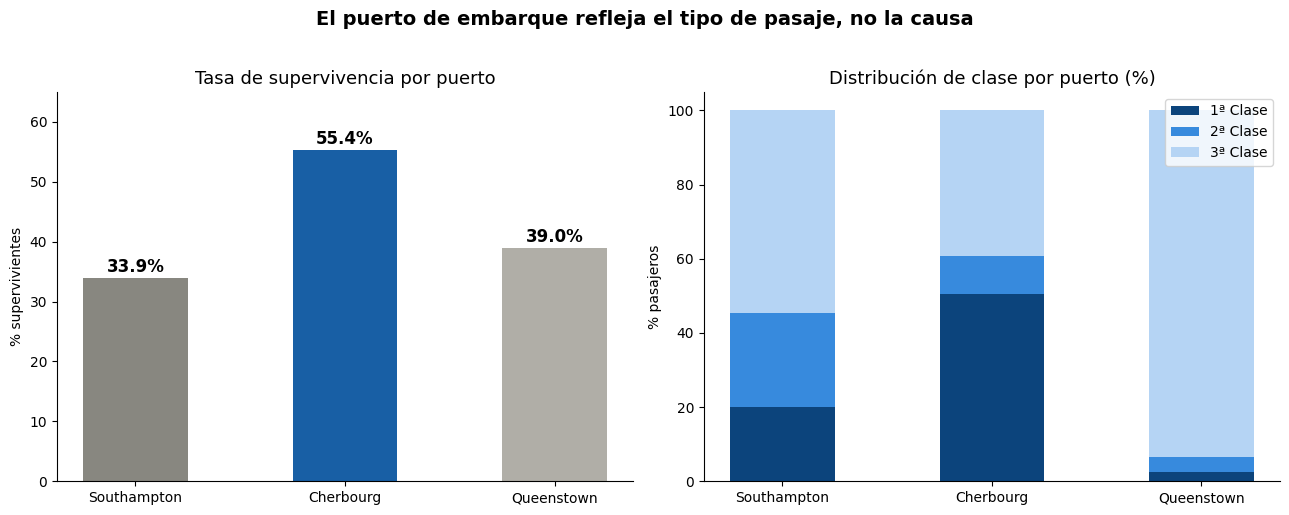

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('El puerto de embarque refleja el tipo de pasaje, no la causa', fontsize=14, fontweight='bold', y=1.02)

orden_puertos = ['Southampton', 'Cherbourg', 'Queenstown']

# Tasa de supervivencia por puerto
rel_puerto = df.groupby(['embark_town', 'alive']).size().unstack(fill_value=0)
rel_puerto = rel_puerto.loc[orden_puertos]
rel_puerto_pct = rel_puerto.div(rel_puerto.sum(axis=1), axis=0) * 100

axes[0].bar(orden_puertos, rel_puerto_pct['yes'],
            color=['#888780', '#185FA5', '#B0AEA7'], width=0.5)
for i, v in enumerate(rel_puerto_pct['yes']):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Tasa de supervivencia por puerto', fontsize=13)
axes[0].set_ylabel('% supervivientes')
axes[0].set_ylim(0, 65)
axes[0].spines[['top', 'right']].set_visible(False)

# Distribución de clase por puerto
clase_puerto = df.groupby(['embark_town', 'pclass']).size().unstack(fill_value=0)
clase_puerto = clase_puerto.loc[orden_puertos]
clase_puerto_pct = clase_puerto.div(clase_puerto.sum(axis=1), axis=0) * 100

bottom1 = clase_puerto_pct[1]
bottom2 = clase_puerto_pct[1] + clase_puerto_pct[2]
colores_clase = ['#0C447C', '#378ADD', '#B5D4F4']

axes[1].bar(orden_puertos, clase_puerto_pct[1], label='1ª Clase', color=colores_clase[0], width=0.5)
axes[1].bar(orden_puertos, clase_puerto_pct[2], bottom=clase_puerto_pct[1], label='2ª Clase', color=colores_clase[1], width=0.5)
axes[1].bar(orden_puertos, clase_puerto_pct[3], bottom=bottom2, label='3ª Clase', color=colores_clase[2], width=0.5)
axes[1].set_title('Distribución de clase por puerto (%)', fontsize=13)
axes[1].set_ylabel('% pasajeros')
axes[1].legend(loc='upper right')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()